# LangGraph

LangGraph is a framework for modeling LLM-based applications as **stateful graphs**. Built on top of LangChain, it supports cycles and conditional branching to express complex agent workflows.

## Core Concepts

| Concept | Description |
|---|---|
| **State** | A data structure shared across the entire graph. Each node reads from and writes to it. |
| **Node** | A function that receives state as input and returns an updated state. |
| **Edge** | Defines transitions between nodes. Can be conditional. |
| **Graph** | A combination of State + Nodes + Edges. Executable after calling `compile()`. |

## Why LangGraph?

- **Cycle support**: Supports graphs with loops, not just simple DAGs (Directed Acyclic Graphs)
- **Persistence**: Built-in checkpointing for state save/restore (human-in-the-loop)
- **Streaming**: Receive each node's execution result as a stream

### Install packages using uv

In [1]:
# uv pip install langgraph langchain-anthropic

### Ollama model import

In [2]:
from langchain_ollama import ChatOllama
OLLAMA_BASE_URL = "http://localhost:11434"
MODEL = "mistral"
model = ChatOllama(model=MODEL, base_url=OLLAMA_BASE_URL)
response = model.invoke("What is the capital of France? Answer shortly.")
print(response.content)

 Paris


## Graph Types and Use Cases

LangGraph provides three graph types. `StateGraph` is used in almost all practical cases.

| Graph | Usage | Description |
|---|---|---|
| `StateGraph` | Very common | General-purpose graph with custom typed state (TypedDict / Pydantic) |
| `MessageGraph` | Rarely used | Simplified graph with fixed `list[BaseMessage]` state — legacy, effectively deprecated |
| Functional API | Growing | Declare graphs with `@entrypoint` / `@task` decorators instead of building a graph object |

The Functional API is convenient for simple linear pipelines, but `StateGraph` is preferable when conditional edges or complex branching are needed.

> LangGraphDeprecatedSinceV10: MessageGraph is deprecated in LangGraph v1.0.0, to be removed in v2.0.0. Please use StateGraph with a `messages` key instead. Deprecated in LangGraph V1.0 to be removed in V2.0.  

## Basic Graph Example #1: Conditional Branching

- Classify a question into one of two categories: "math", "emotion" and reply with a relevant answer.
- LLM classifies the question.


### Function declaration

In [3]:
from langchain_core.tools import tool

@tool
def calculate(expression: str) -> str:
    """Calculate a math expression."""
    return str(eval(expression, {"__builtins__": {}}, {}))

@tool
def analyze_sentiment(text: str) -> str:
    """Classify the text as positive or negative."""
    prompt = (
        "Classify the sentiment of the following text. "
        "Answer with only 'positive' or 'negative'.\n"
        f"Text: {text}"
    )
    return model.invoke(prompt).content

## State

State is defined with `TypedDict`. Using `Annotated` with `operator.add` allows values to be **accumulated (appended)** instead of overwritten.

In [4]:
from typing import TypedDict, Literal

class State(TypedDict):
    text: str
    classified: Literal["math", "emotion"]
    result: str

### MessageState

`MessagesState` is a built-in `TypedDict` provided by LangGraph. Its `messages` field uses `add_messages` as a **reducer** — instead of overwriting the list on every node return, it appends new messages.

```python
# Equivalent definition
class MessagesState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
```

| Behavior | Plain list field | `Annotated[..., add_messages]` |
|---|---|---|
| Node returns `{"messages": [msg]}` | Overwrites the whole list | Appends `msg` to the existing list |
| Duplicate message ID | — | Replaces the existing message with the same ID |

### Message Types

| Class | Role | Typical `role` value |
|---|---|---|
| `HumanMessage` | User input | `"user"` |
| `AIMessage` | Model response (may contain `tool_calls`) | `"assistant"` |
| `SystemMessage` | System-level instruction | `"system"` |
| `ToolMessage` | Tool execution result (linked by `tool_call_id`) | `"tool"` |

In [5]:
from typing import Annotated, TypedDict
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def reply(state: ChatState) -> dict:
    last = state["messages"][-1]
    return {"messages": [AIMessage(content=f"Echo: {last.content}")]}

builder = StateGraph(ChatState)
builder.add_node("reply", reply)
builder.add_edge(START, "reply")
builder.add_edge("reply", END)
app = builder.compile()

# The reducer appends AIMessage alongside the existing HumanMessage — no overwrite
result = app.invoke({"messages": [HumanMessage(content="Hello")]})
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hello
AIMessage : Echo: Hello


### Custom State with Messages

When the graph needs both conversation history and additional fields (e.g., a user ID or intermediate flags), extend `MessagesState` or define a custom `TypedDict` with the `add_messages` reducer applied to the `messages` field.

In [6]:
from typing import Annotated, TypedDict
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

# Option A: extend MessagesState
class MyState(MessagesState):
    user_id: str
    step: int

# Option B: define from scratch with the reducer
class MyStateB(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    user_id: str
    step: int

## Nodes

A node is a function that takes `State` as input and returns **a dict containing only the fields to update**.

In [7]:
from langgraph.graph import StateGraph
from pydantic import BaseModel

class Classification(BaseModel):
    classified: Literal["math", "emotion"]
classifier = model.with_structured_output(Classification)

def classify(state: State):
    result = classifier.invoke(
        f"""
Classify the following input.

- math: an addition or subtraction expression
- emotion: a sentence containing emotion

Input: {state["text"]}
"""
    )
    return {"classified": result.classified}

graph = StateGraph(State)
graph.add_node("classify", classify)

## Edges

### Normal Edge
Always moves from A → B.

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)
graph.add_node("classify", classify)
graph.add_edge(START, "classify")
graph.add_edge("classify", END)

app = graph.compile()
print(app.invoke({"text": "I am so sad."}))
print(app.invoke({"text":"10+3"}))

{'text': 'I am so sad.', 'classified': 'emotion'}
{'text': '10+3', 'classified': 'math'}


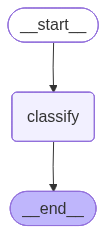

In [9]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

### Conditional Edge
Specifies a router function that inspects state to decide the next node. The router returns a string key that maps to the target node.

In [10]:
def run_calculate(state: State):
    return {
        "result": calculate.invoke({
            "expression": state["text"]
        })
    }


def run_sentiment(state: State):
    return {
        "result": analyze_sentiment.invoke({
            "text": state["text"]
        })
    }

In [11]:
from langgraph.graph import StateGraph, START, END

def route(state: State) -> Literal["calculate", "sentiment"]:
    return "calculate" if state["classified"] == "math" else "sentiment"

graph = StateGraph(State)

graph.add_node("classify", classify)
graph.add_node("calculate", run_calculate)
graph.add_node("sentiment", run_sentiment)

graph.add_edge(START, "classify")
graph.add_conditional_edges("classify", route)
graph.add_edge("calculate", END)
graph.add_edge("sentiment", END)

app = graph.compile()
print(app.invoke({"text":"10+3"}))
print(app.invoke({"text": "I am so sad."}))

{'text': '10+3', 'classified': 'math', 'result': '13'}
{'text': 'I am so sad.', 'classified': 'emotion', 'result': ' Negative'}


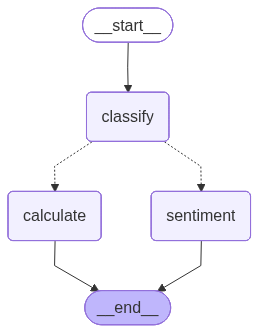

In [12]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

This enables **branching**: one node can fan out to different paths depending on runtime state.

## Basic Graph Example #2: Cyclic Graph

A cyclic graph where, if the LLM calls a tool, it passes through the `tools` node and loops back to `agent`.

In [13]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

'''
def tools_condition(state: MessagesState) -> bool:
    last_message = state["messages"][-1]
    return last_message.content.startswith("Use tool:")
'''

tools = [calculate]
model_with_tools = model.bind_tools(tools)

def agent(state: MessagesState) -> dict:
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(MessagesState)
builder.add_node("agent", agent)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)  # → "tools" or END
builder.add_edge("tools", "agent")  # Cycle: return to agent after tool execution
builder.add_edge("tools", END)

graph = builder.compile()

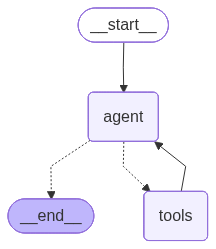

In [14]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [15]:
result = graph.invoke({"messages": "What is 10 + 3?"})
print(result["messages"][-1].content)

 The sum of 10 and 3 is 13.


## Streaming

`stream()` yields updates from each node in order.

In [16]:
for event in graph.stream(
    {"messages": [HumanMessage(content="What is 25 + 17?")]},
    stream_mode="updates",
):
    node_name, update = next(iter(event.items()))
    print(f"[{node_name}]", update["messages"][-1].content[:80])

[agent] 
[tools] 42
[agent]  The sum of 25 and 17 is 42.


## Checkpointing (Persistence)

Attaching `MemorySaver` saves state per `thread_id`, allowing conversations to resume across turns.

In [17]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph_with_memory = builder.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "session-1"}}

# First turn
graph_with_memory.invoke(
    {"messages": [HumanMessage(content="My name is Alice.")]},
    config=config,
)

# Second turn — previous state is automatically carried over
result = graph_with_memory.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config=config,
)
print(result["messages"][-1].content)

 Your name, as per our initial conversation, is Alice.

```json
[{"name":"calculate","arguments":{"expression":"2+3"}}]
```

The result of the calculation is `5`. Is there anything else you need help with?
